## Import de librerías

In [112]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit
import math


## Import de dataset

In [113]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/04-null-processed/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)


1 files merged
(2933082, 24)


## Análisis de outliers

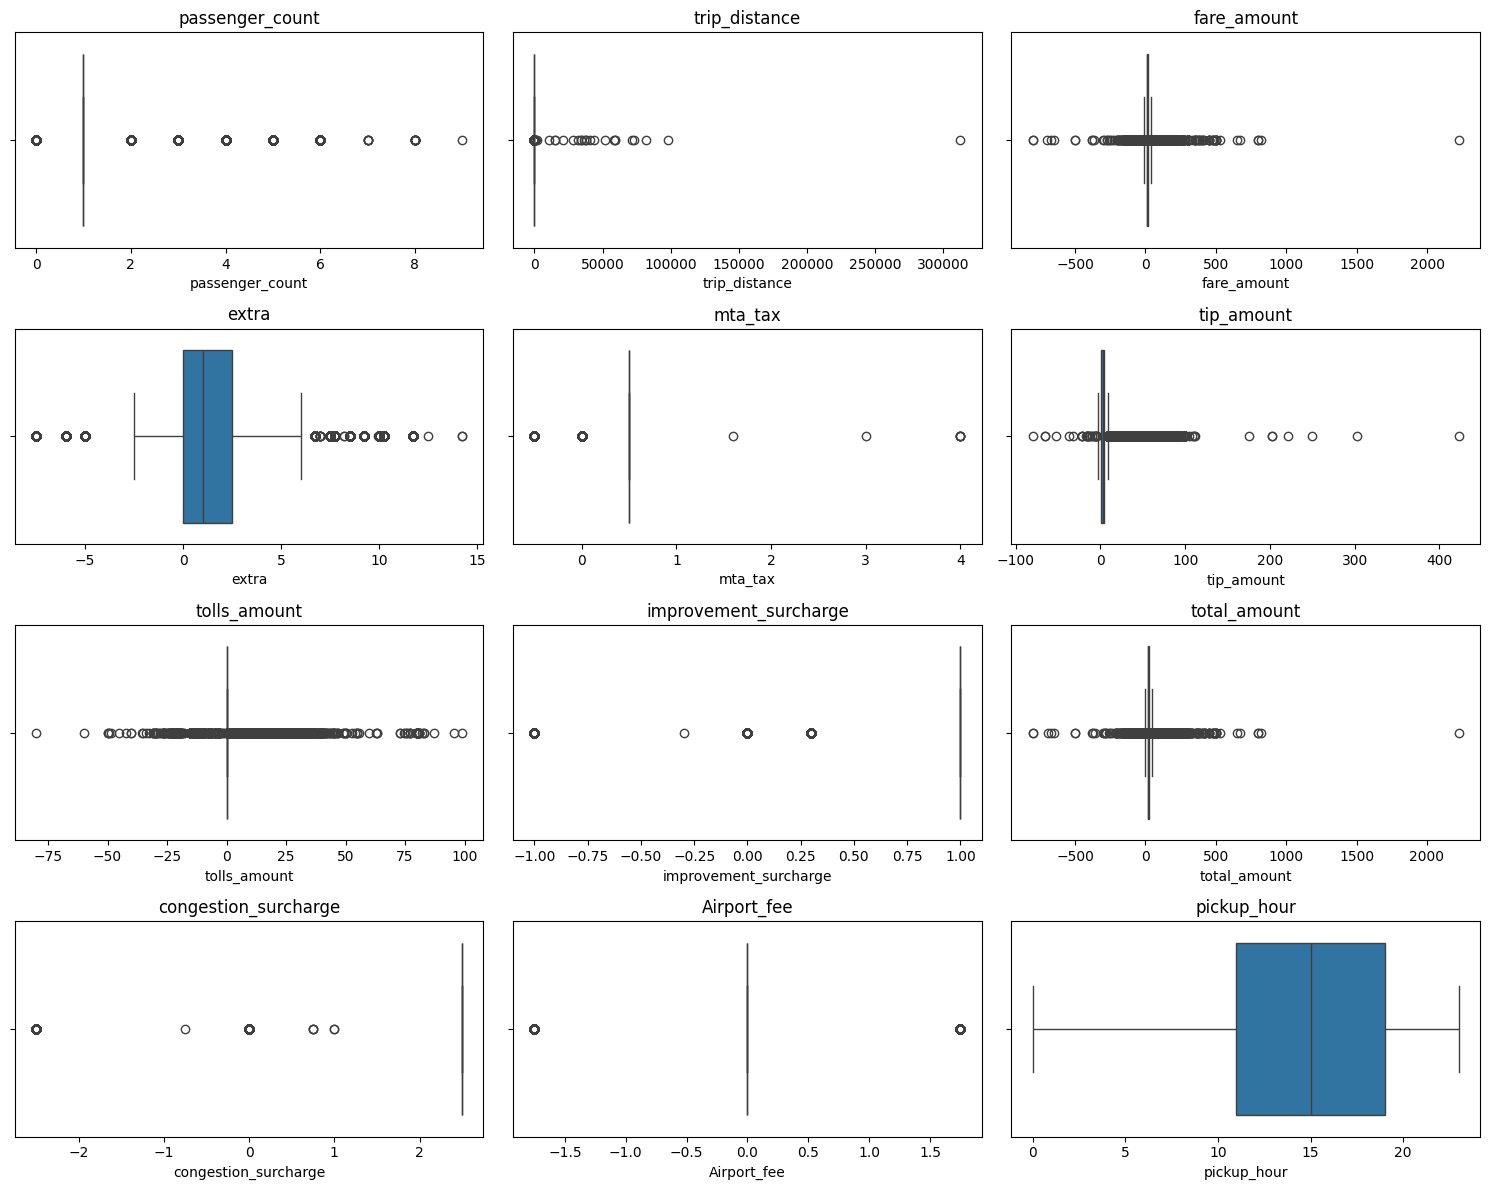

In [114]:

# columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols)

# definimos número de filas y columnas del grid
cols = 3   # puedes cambiarlo a 2, 4, etc.
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

## Ajuste de negativos

In [115]:
# ninguna de las columnas numéricas debería tener valores negativos, pasamos a valor absoluto
for col in num_cols:
    df[col] = df[col].abs()

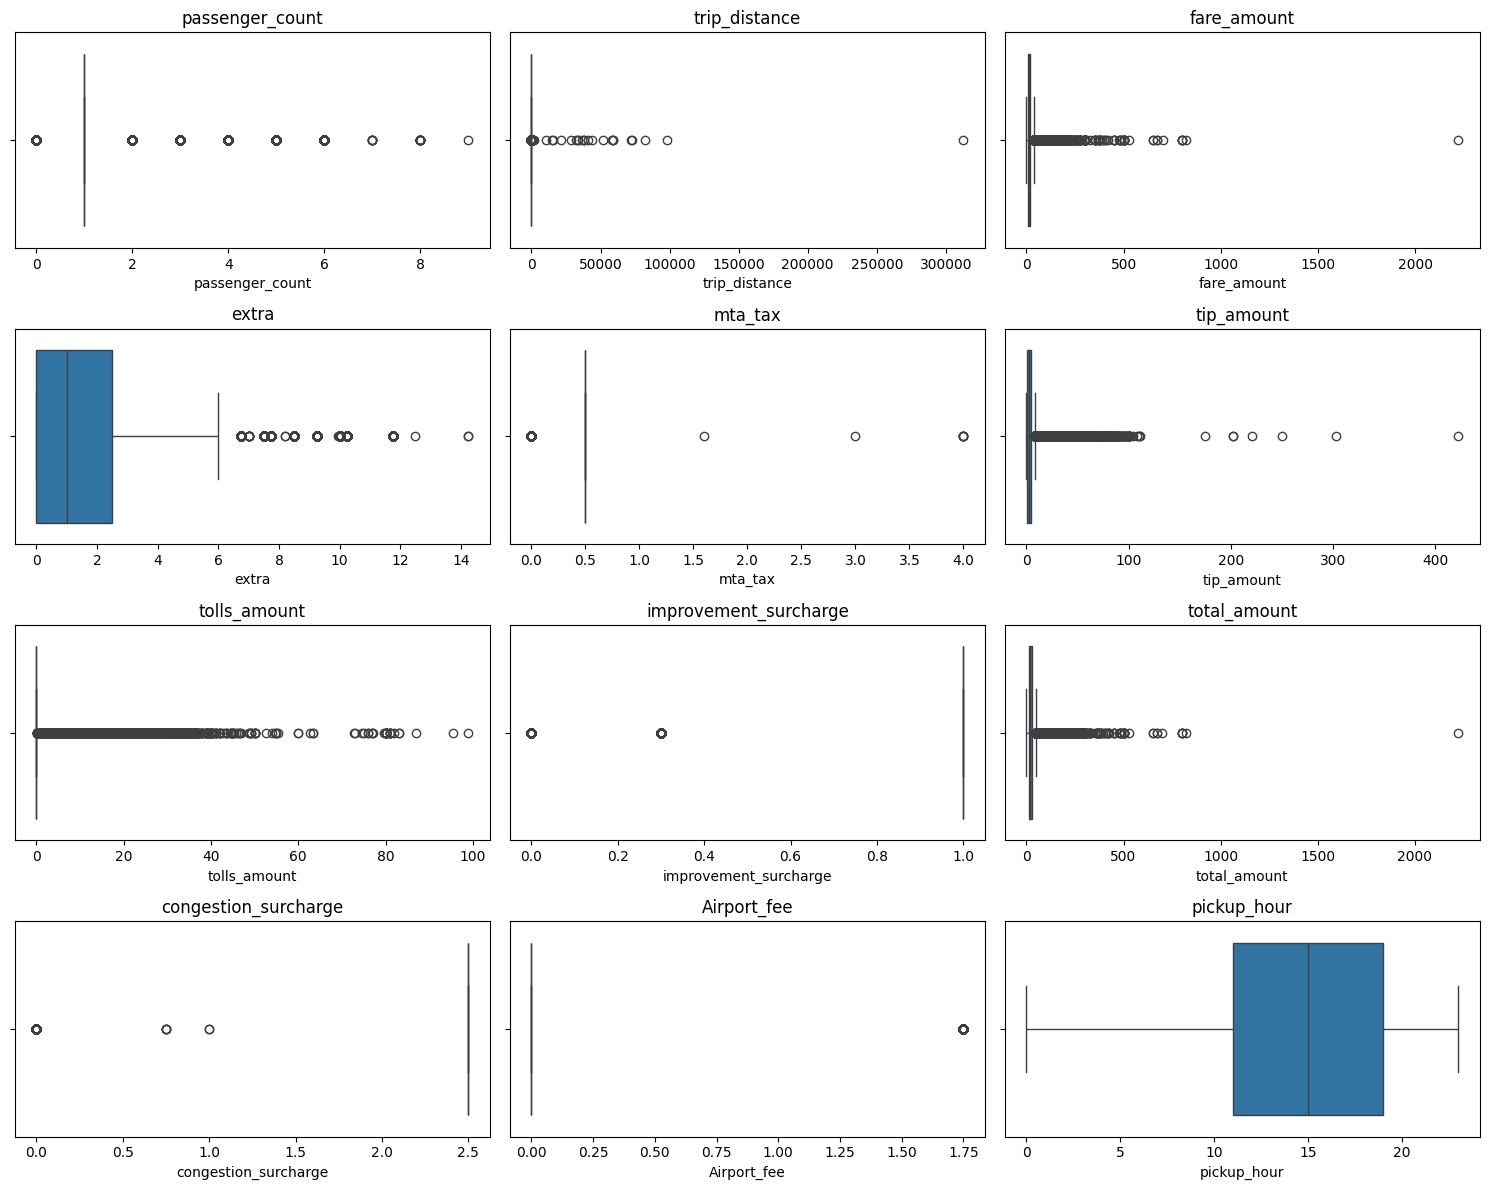

In [116]:

# columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols)

# definimos número de filas y columnas del grid
cols = 3   # puedes cambiarlo a 2, 4, etc.
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

## Seteo de IQRs

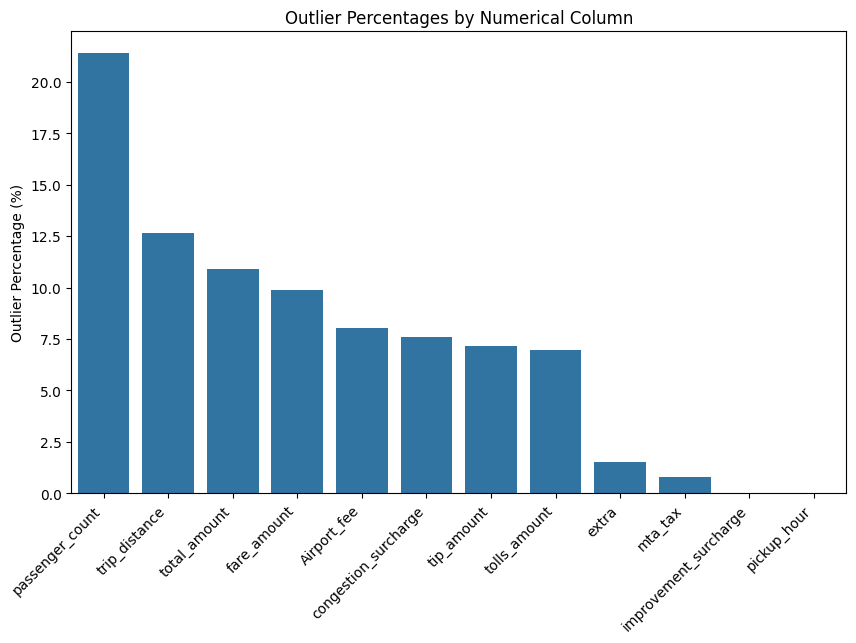

In [117]:
iqr_ranges = {}

for col in num_cols:
    series = df[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_ranges[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LowerBound": lower,
        "UpperBound": upper
    }

# grafico barras porcentajes de outliers por columna numérica
outlier_percentages = {}
for col in num_cols:
    lower = iqr_ranges[col]["LowerBound"]
    upper = iqr_ranges[col]["UpperBound"]
    
    total_count = len(df)
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    outlier_percentage = (outlier_count / total_count) * 100
    outlier_percentages[col] = outlier_percentage
# gráfico de barras ordenado mayor a menor
outlier_percentages = dict(sorted(outlier_percentages.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6)) 
sns.barplot(x=list(outlier_percentages.keys()), y=list(outlier_percentages.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outlier Percentage (%)')
plt.title('Outlier Percentages by Numerical Column')
plt.show()


## Outlier treatment

### Passenger count

In [118]:
# cualquier valor por encima de 5 para passenger_count lo tomamos como outlier. 
df = df[df['passenger_count'] <= 5]
df = df[df['passenger_count'] >= 1]

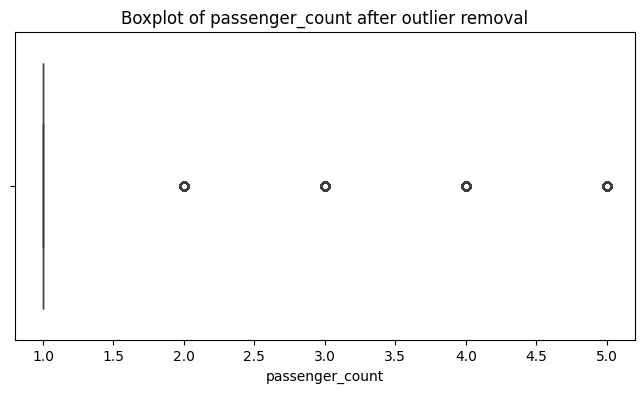

In [119]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['passenger_count'])
plt.title(f'Boxplot of passenger_count after outlier removal')
plt.show()

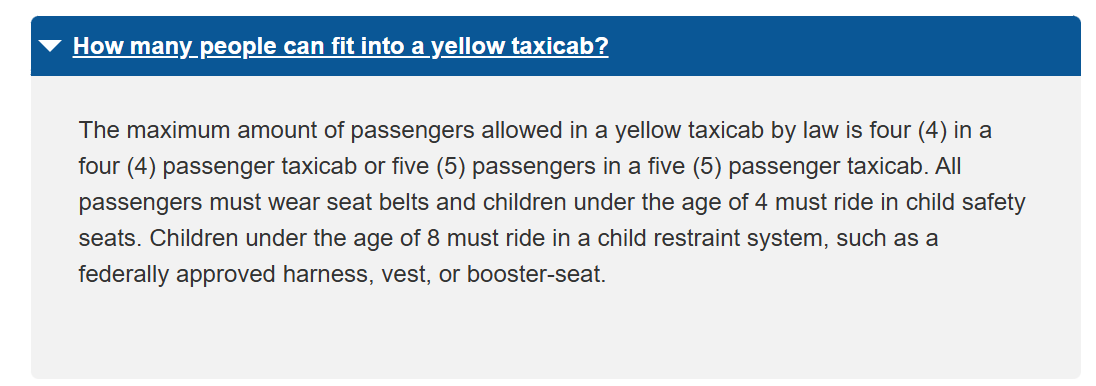


[fuente](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page)

### Trip distance

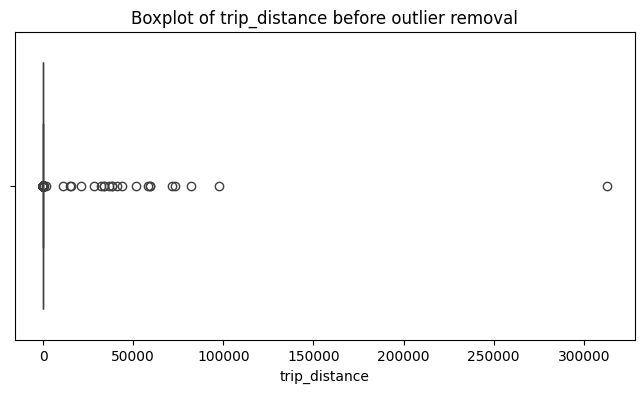

In [120]:
# boxplot de trip_distance
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['trip_distance'])
plt.title(f'Boxplot of trip_distance before outlier removal')
plt.show()

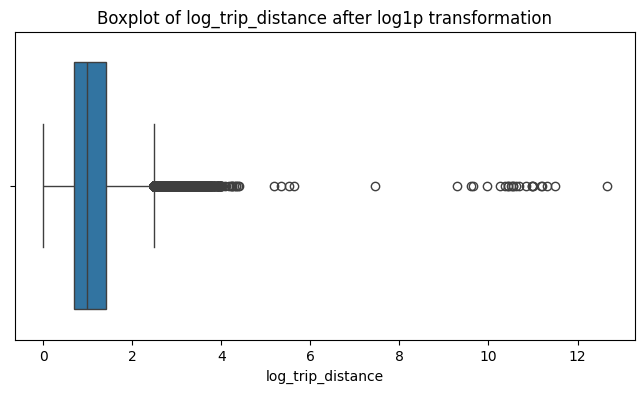

In [121]:
# Adoptamos tactica de pasar variable a logaritmica para reducir el efecto de outliers
df['log_trip_distance'] = np.log1p(df['trip_distance'])
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['log_trip_distance'])
plt.title(f'Boxplot of log_trip_distance after log1p transformation')
plt.show()

In [122]:
# sacamos outliers de log_trip_distance
q1 = df['log_trip_distance'].quantile(0.25)
q3 = df['log_trip_distance'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df = df[(df['log_trip_distance'] >= lower_bound) & (df['log_trip_distance'] <= upper_bound)]
# agregar log_trip_distance a num_cols y metricas a iqr_ranges
num_cols.append('log_trip_distance')
iqr_ranges['log_trip_distance'] = {
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "LowerBound": lower_bound,
    "UpperBound": upper_bound
}



In [123]:
# dropeamos trip_distance ya que tenemos log_trip_distance
df = df.drop(columns=['trip_distance'])

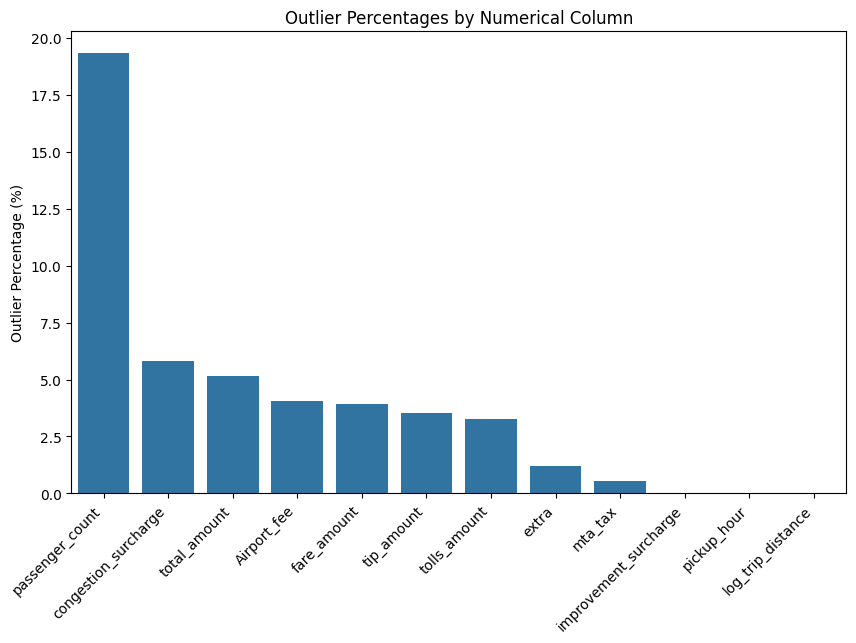

In [124]:
# grafico barras porcentajes de outliers por columna numérica
num_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_percentages = {}
for col in num_cols:
    lower = iqr_ranges[col]["LowerBound"]
    upper = iqr_ranges[col]["UpperBound"]
    
    total_count = len(df)
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    outlier_percentage = (outlier_count / total_count) * 100
    outlier_percentages[col] = outlier_percentage
# gráfico de barras ordenado mayor a menor
outlier_percentages = dict(sorted(outlier_percentages.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6)) 
sns.barplot(x=list(outlier_percentages.keys()), y=list(outlier_percentages.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outlier Percentage (%)')
plt.title('Outlier Percentages by Numerical Column')
plt.show()

### Congestion surcharge

In [125]:
# valores unicos para congestion_surcharge
print(df['congestion_surcharge'].value_counts())

congestion_surcharge
2.50    2542234
0.00     156767
0.75          4
1.00          2
Name: count, dtype: int64


In [126]:
# valores que no sean 0 ni 2.5 los pasamos a 2.5
df['congestion_surcharge'] = df['congestion_surcharge'].apply(lambda x: 2.5 if x not in [0, 2.5] else x)

### Improvement surcharge

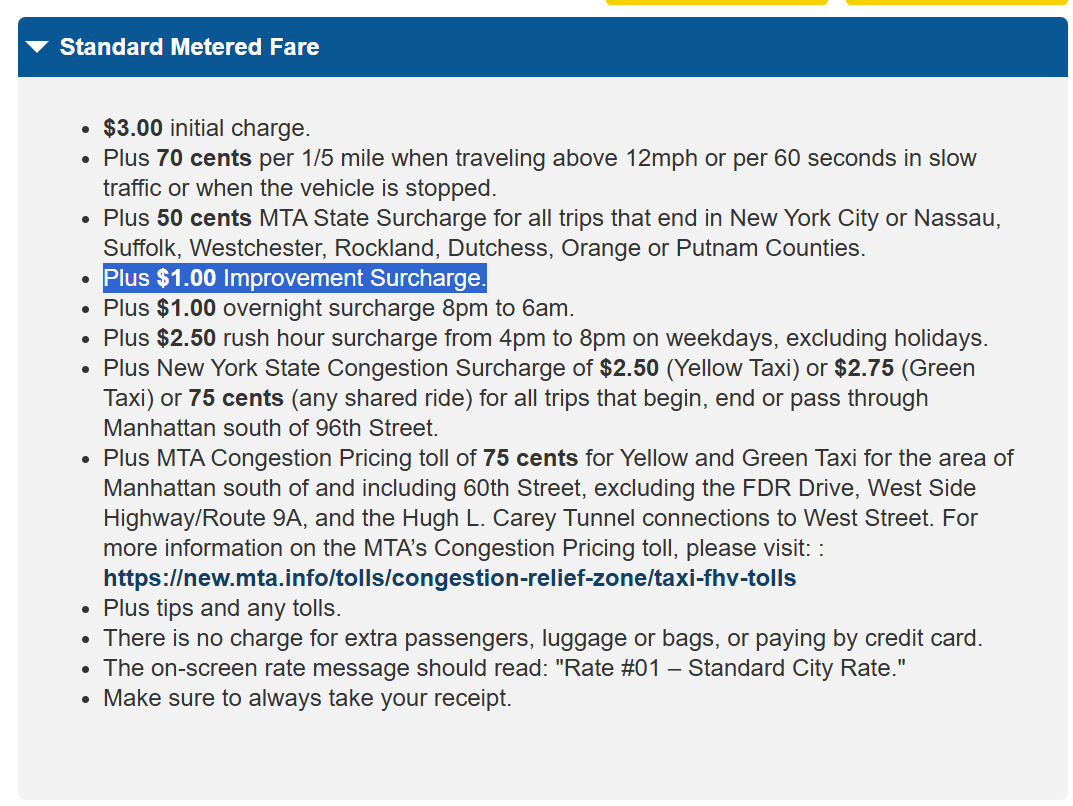

In [127]:
# asumimos que los valores de improvement_surcharge que no son ni 0 ni 1 son errores. les asignamos el valor 1. 
df['improvement_surcharge'] = df['improvement_surcharge'].apply(lambda x: 1 if x not in [0, 1] else x)

### Mta tax

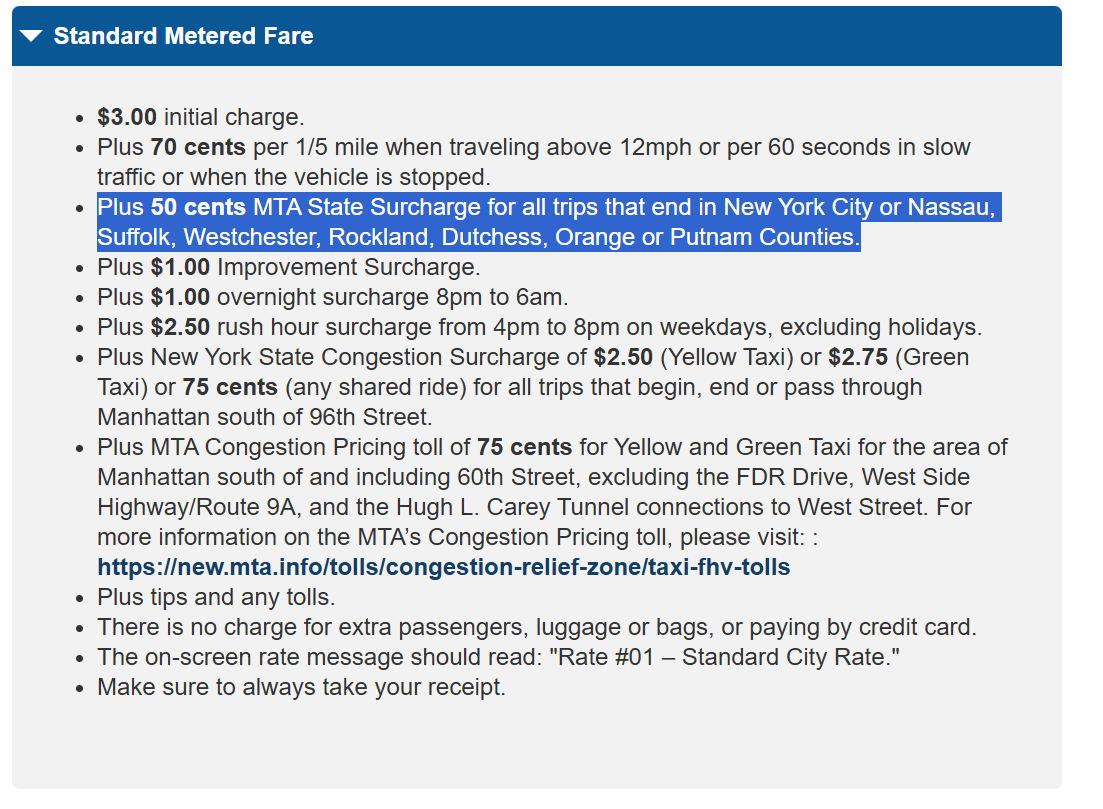

In [128]:
# valores unicos para mta tax
print(df['mta_tax'].value_counts())

mta_tax
0.50    2683988
0.00      15015
4.00          2
1.60          1
3.00          1
Name: count, dtype: int64


In [129]:
# Son pocos. probablemente errores de data entry. los pasamos a 0.5
df['mta_tax'] = df['mta_tax'].apply(lambda x: 0.5 if x not in [0, 0.5] else x)


### Toll amount

In [137]:
# 1) Serie sin ceros
tolls_nonzero = df[df['tolls_amount'] > 0]['tolls_amount']

# 2) Calcular IQR
q1 = tolls_nonzero.quantile(0.25)
q3 = tolls_nonzero.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# 3) Detectar outliers reales (solo en valores > 0)
outliers_mask = (df['tolls_amount'] > 0) & (
    (df['tolls_amount'] < lower) | (df['tolls_amount'] > upper)
)

outlier_count = outliers_mask.sum()

# 4) Filtrar los outliers
df_filtered = df[~outliers_mask]

# 5) Métricas
total_count = len(df_filtered)
print(f"Outliers detected: {outlier_count}")
print(f"Rows after filtering: {total_count}")
print(f"Percentage removed: {(outlier_count/(outlier_count+total_count))*100:.2f}%")

df = df_filtered


Outliers detected: 3112
Rows after filtering: 2695895
Percentage removed: 0.12%


### Tip amount

In [138]:
# 1) Serie sin ceros
tip_nonzero = df[df['tip_amount'] > 0]['tip_amount']

# 2) Calcular IQR
q1 = tip_nonzero.quantile(0.25)
q3 = tip_nonzero.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# 3) Detectar outliers
outliers_mask = (df['tip_amount'] > 0) & ((df['tip_amount'] < lower) | (df['tip_amount'] > upper))
outlier_count = outliers_mask.sum()

# 4) Filtrar outliers
df_filtered = df[~outliers_mask]

# 5) Resultados
total_count = len(df_filtered)
print(f"Outliers detected: {outlier_count}")
print(f"Dataset size after filtering: {total_count}")
print(f"Percentage removed: {(outlier_count/(outlier_count+total_count))*100:.2f}%")

df = df_filtered


Outliers detected: 127198
Dataset size after filtering: 2568697
Percentage removed: 4.72%


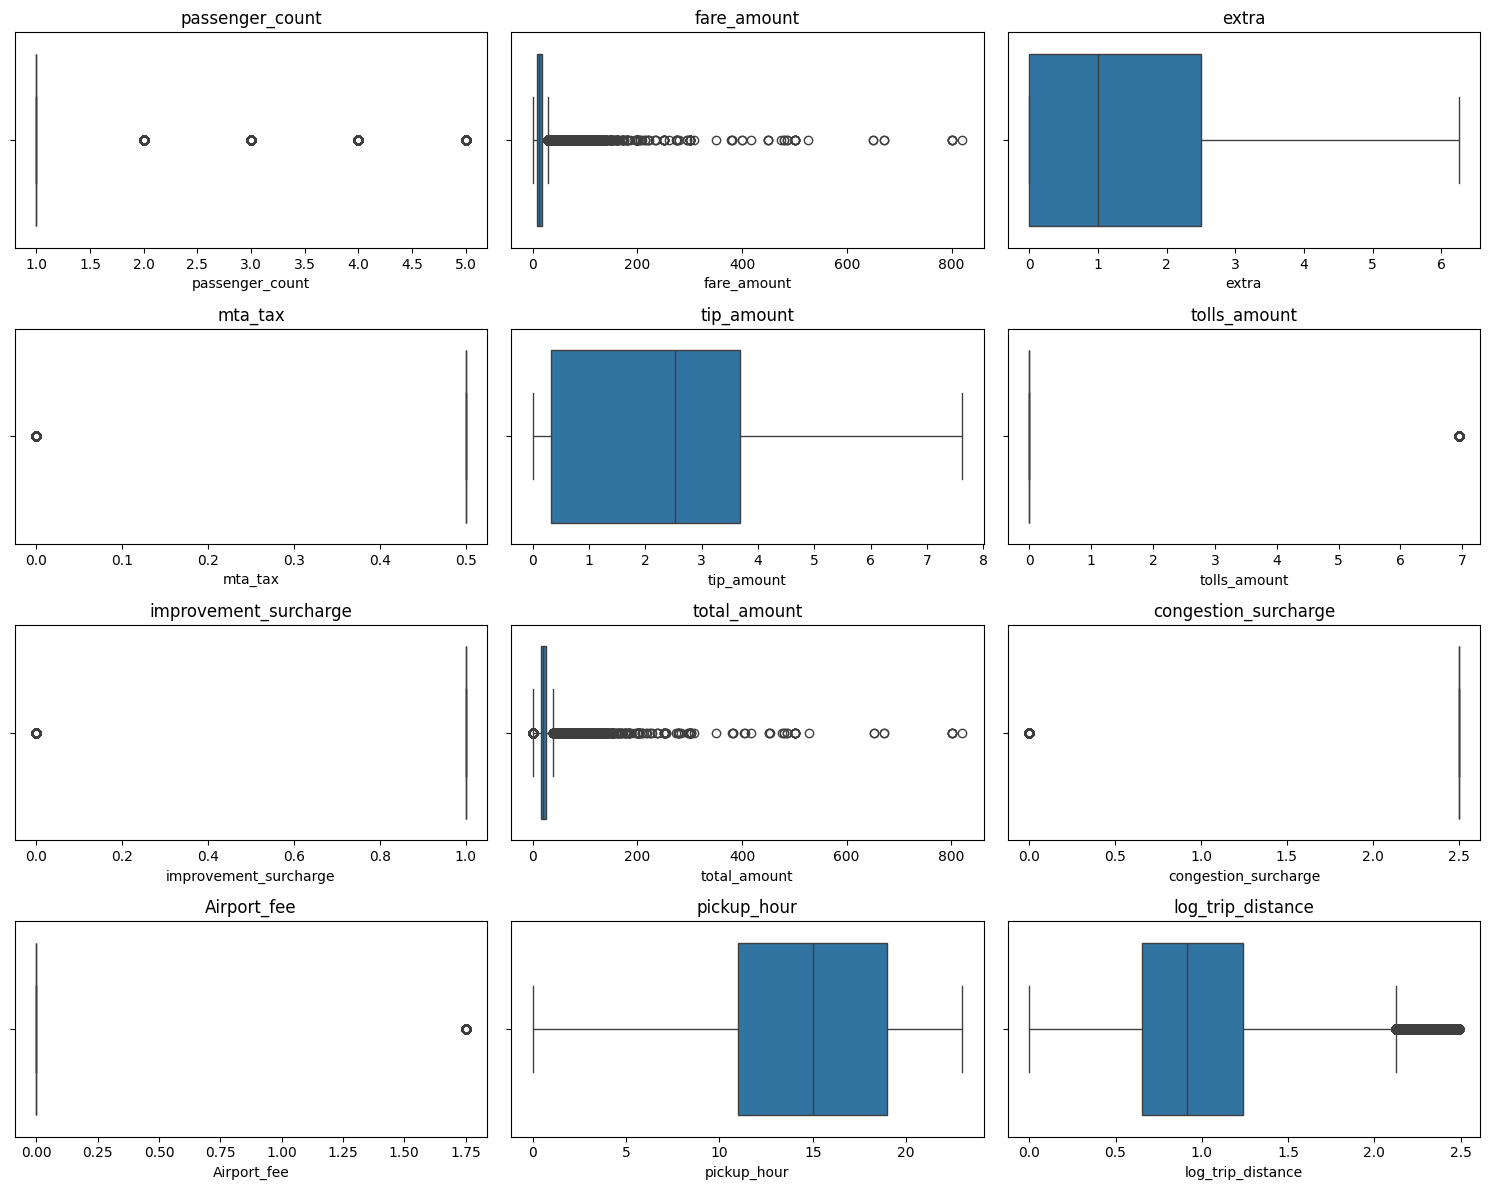

In [139]:

# columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols)

# definimos número de filas y columnas del grid
cols = 3   # puedes cambiarlo a 2, 4, etc.
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

### Extra

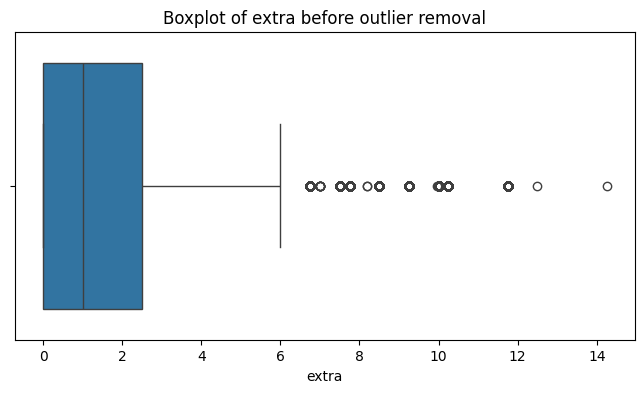

Outliers detected in 'extra': 4194


In [133]:
# outliers columna "Extra"
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['extra'])
plt.title(f'Boxplot of extra before outlier removal')
plt.show()
# cantidad
outlier_count = df[(df['extra'] < 0) | (df['extra'] > 10)].shape[0]
print(f"Outliers detected in 'extra': {outlier_count}")

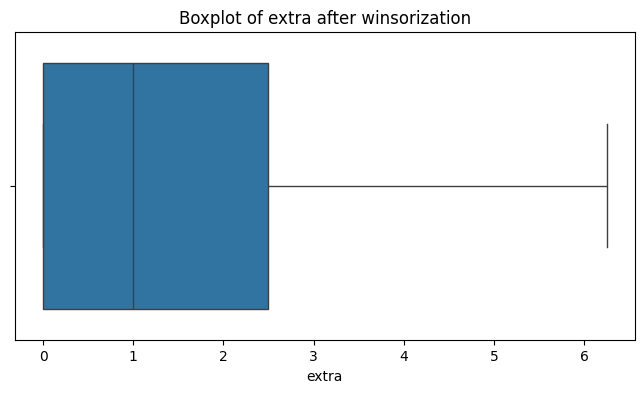

In [140]:
# Calcular IQR
q1 = df['extra'].quantile(0.25)
q3 = df['extra'].quantile(0.75)
iqr = q3 - q1

# Límite superior según IQR
upper = q3 + 1.5 * iqr

# Winsorizar: limitar valores al upper bound
df['extra'] = df['extra'].clip(upper=upper)
# Boxplot después de winsorización
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['extra'])
plt.title(f'Boxplot of extra after winsorization')
plt.show()

### Fare amount

In [153]:
## fare amount no puede ser 0. eliminamos esos registros
df = df[df['fare_amount'] > 0]

In [154]:
## outliers y count de outliers fare_amount
# Calcular IQR
q1 = df['fare_amount'].quantile(0.25)
q3 = df['fare_amount'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_count = df[(df['fare_amount'] < lower) | (df['fare_amount'] > upper)].shape[0]
print(f"Outliers detected in 'fare_amount': {outlier_count}")
#porcentaje
print(f"Percentage of outliers in 'fare_amount': {(outlier_count/len(df))*100:.2f}%")

Outliers detected in 'fare_amount': 0
Percentage of outliers in 'fare_amount': 0.00%


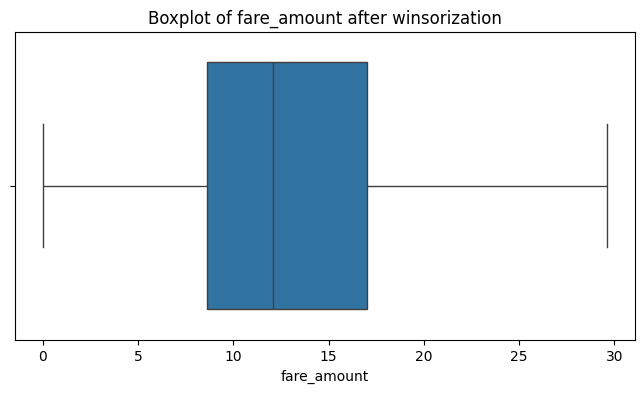

In [156]:
# winsorización de fare_amount
df['fare_amount'] = df['fare_amount'].clip(lower=lower, upper=upper)
# Boxplot después de winsorización
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['fare_amount'])
plt.title(f'Boxplot of fare_amount after winsorization')
plt.show()

### Total amount

In [157]:
# total amount calculated
df['total_amount_calculated'] = (
    df['fare_amount'] +
    df['extra'] +
    df['mta_tax'] +
    df['tip_amount'] +
    df['tolls_amount'] +
    df['improvement_surcharge'] +
    df['congestion_surcharge']
)

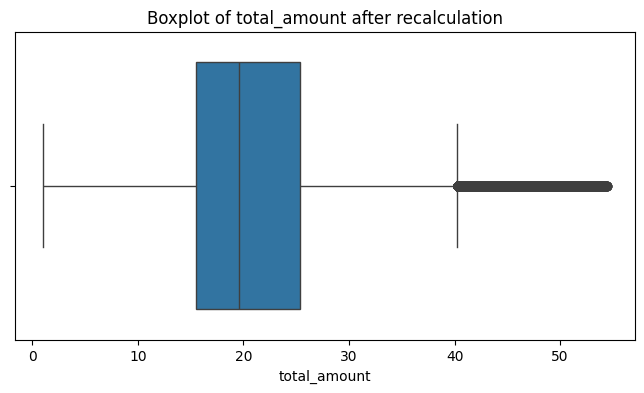

In [158]:
# Se recalcula total_amount con los valores corregidos
df['total_amount'] = df['total_amount_calculated']
# boxplot de total_amount
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['total_amount'])
plt.title(f'Boxplot of total_amount after recalculation')
plt.show()


In [159]:
## analisis de outliers de total_amount 
# cantidad de outliers sumarizados basado en ieqr_ranges
q1 = df['total_amount'].quantile(0.25)
q3 = df['total_amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = df[(df['total_amount'] < lower_bound) | (df['total_amount'] > upper_bound)].shape[0]
print(f"Outliers detected in 'total_amount': {outlier_count}")
# porcentual
total_count = len(df)
print(f"Percentage of outliers in 'total_amount': {(outlier_count/total_count)*100:.2f}%")

Outliers detected in 'total_amount': 60784
Percentage of outliers in 'total_amount': 2.37%


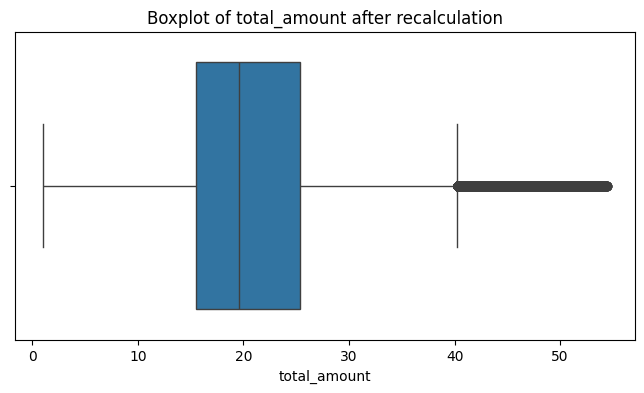

In [160]:
# registros que son total_amount = 0 son errores. los eliminamos
df = df[df['total_amount'] > 0]

# Se recalcula total_amount con los valores corregidos
df['total_amount'] = df['total_amount_calculated']
# boxplot de total_amount
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['total_amount'])
plt.title(f'Boxplot of total_amount after recalculation')
plt.show()


## Export de dataset 

In [161]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
# agregamos columna mes y separamos
df['month'] = df['tpep_pickup_datetime'].dt.month
for month, group in df.groupby('month'):
    group.drop(columns=['month'], inplace=True)
    group.to_parquet(f"../dataset/05-outliers-processed/yellow_tripdata_2024-{month:02d}.parquet", index=False)


---------------------

## Idea de ML

## 🟨 Objetivo del proyecto

Desarrollar un modelo de Machine Learning que recomiende a los taxistas de NYC la mejor **zona** para posicionarse en cada **franja horaria** y **día de la semana**, con el fin de **maximizar su ganancia esperada**.

---

## 🗂️ Unidad de análisis

Cada fila del dataset agregado representa una combinación de:

- **Zona** (Taxi Zone)
- **Franja horaria** (hora del día)
- **Día de la semana**

Ejemplo: *Midtown Center – 17:00 – Lunes*

---

## 📊 Variables clave calculadas por zona–hora–día

Para cada combinación se obtienen métricas históricas:

- **Número de viajes** iniciados en esa zona  
- **Ganancia promedio** del viaje (`total_amount` limpio)  
- **Revenue esperado**:  
  \[
  \text{revenue} = \text{n° de viajes} \times \text{ganancia media}
  \]

Esta última es la variable objetivo del modelo.

---

## 🤖 Modelo de predicción

Se entrena un modelo (Random Forest / XGBoost) que toma como entrada:

- zona  
- franja horaria  
- día de la semana  

Y predice:

- **revenue esperado** para cada zona en ese momento.

---

## 🧭 Recomendación para el taxista

Para una fecha y hora dadas, el modelo predice el revenue esperado en **todas las zonas** y recomienda:

> **La zona con mayor revenue esperado**,  
> es decir, donde el taxista tiene mayor probabilidad de conseguir un viaje y maximizar su ganancia por hora.

---

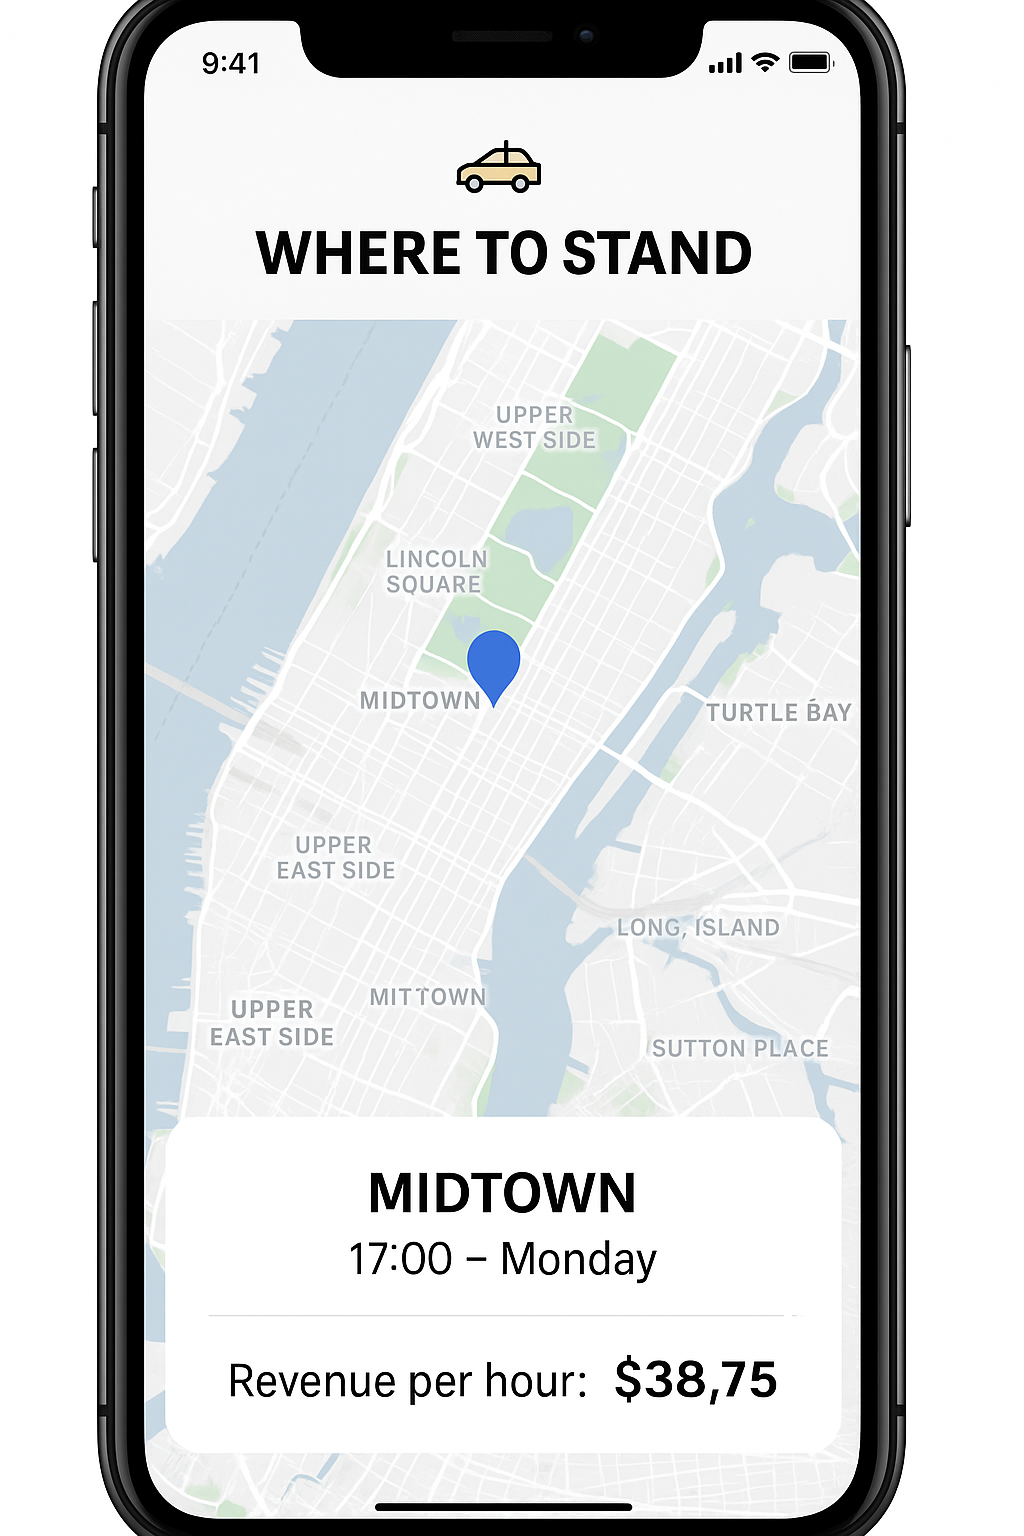
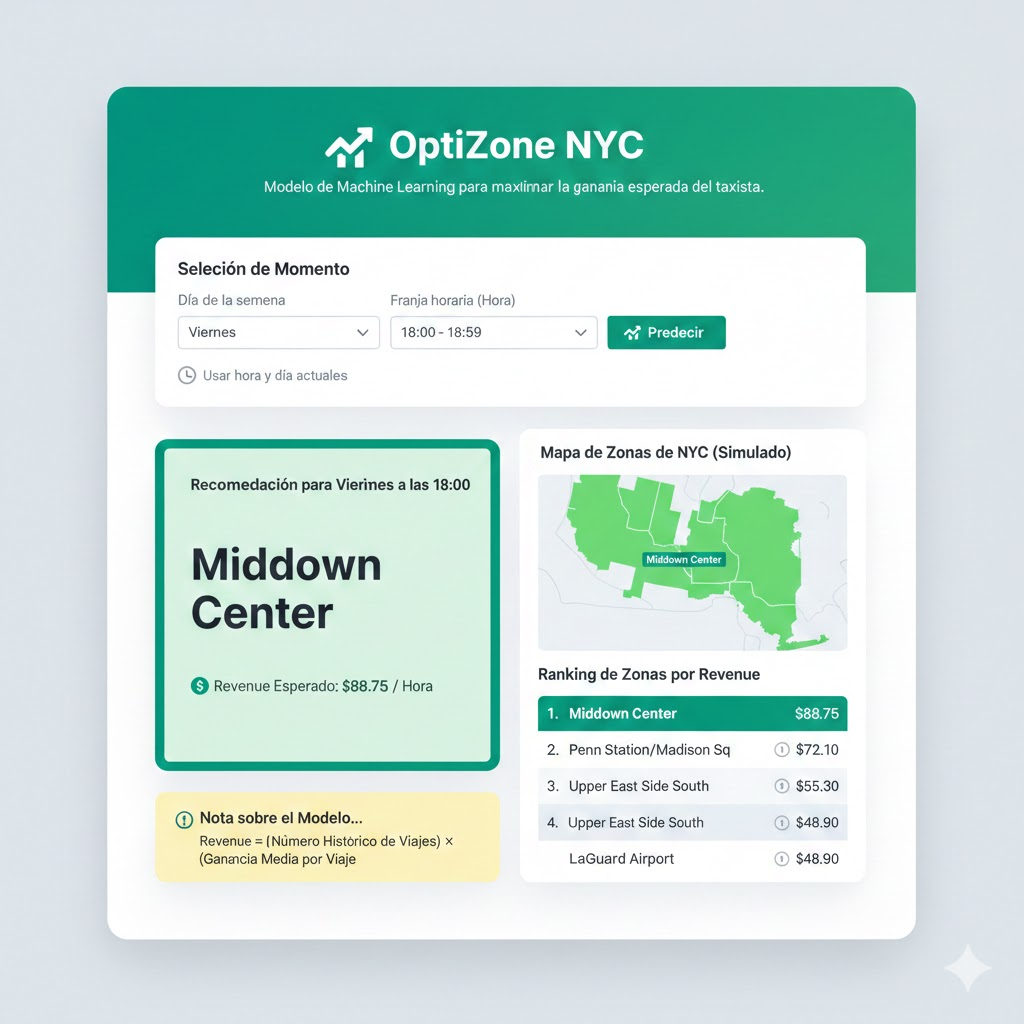